# Stage 01 — Baseline τ search (no ML)

Bayesian optimisation over the 6-dim maintenance interval vector $(\tau_{C1}, \dots, \tau_{C6})$ using Optuna. Each trial runs the deterministic SDG simulator on a stratified subset of printers (one per city) and scores them with the penalised cost / availability objective from `ml_models.lib.objective`.

Top-K trials are re-evaluated on the **full 100-printer fleet** for the final leaderboard. The winner is saved to `results/best_tau.yaml`.

**Tip:** the Optuna study is persisted to a local SQLite file (`results/study.db`), so this notebook is resumable: re-running the search cell continues the same study.

In [1]:
from __future__ import annotations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import yaml

from ml_models.lib.env_runner import default_dates, run_with_tau
from ml_models.lib.objective import scalar_objective
from ml_models.lib.plotting import plot_pareto_cost_availability
from ml_models import PROJECT_ROOT
from sdg.generate import build_printer_city_map, load_configs
from sdg.schema import COMPONENT_IDS

RESULTS_DIR = PROJECT_ROOT / 'ml_models/01_baseline/results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
STUDY_PATH = RESULTS_DIR / 'study.db'
BEST_TAU_PATH = RESULTS_DIR / 'best_tau.yaml'

print('Optuna version:', optuna.__version__)
print('Components:', COMPONENT_IDS)

from ml_models.lib.fast import N_OPTUNA_TRIALS, PARALLEL, banner
banner()


Optuna version: 4.8.0
Components: ('C1', 'C2', 'C3', 'C4', 'C5', 'C6')


[fast] mode=FULL · parallel=12 · trials=200/500 · K=60 · epochs=20/3 · ppo_ts=2000/20000 · seeds=(0, 1, 2)


## Search space and printer subset

Per-component log-uniform priors anchored on `digital_twin_hp_metal_jet_s100_spec.md` §6 (operative ranges of $\tau_{nom}$). The trial subset uses one printer per city so each trial costs roughly 15× one-printer simulations — cheap enough for hundreds of trials, diverse enough to capture climate effects.

In [2]:
TAU_RANGES = {
    'C1': (50.0, 2_000.0),
    'C2': (500.0, 20_000.0),
    'C3': (50.0, 500.0),
    'C4': (100.0, 2_000.0),
    'C5': (500.0, 8_000.0),
    'C6': (1_000.0, 20_000.0),
}

components_cfg, couplings_cfg, cities_cfg = load_configs()
printer_city_map = build_printer_city_map(list(cities_cfg['cities']))

seen: set[str] = set()
TRIAL_PRINTER_IDS: list[int] = []
for printer_id, profile in enumerate(printer_city_map):
    name = profile['name']
    if name not in seen:
        seen.add(name)
        TRIAL_PRINTER_IDS.append(printer_id)
DATES = default_dates()

print('Stratified printers (one per city):', TRIAL_PRINTER_IDS)
print('Days per printer:', len(DATES))

Stratified printers (one per city): [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
Days per printer: 3653


In [3]:
def trial_to_tau(trial: optuna.Trial) -> dict[str, float]:
    return {
        component_id: trial.suggest_float(f'tau_{component_id}', low, high, log=True)
        for component_id, (low, high) in TAU_RANGES.items()
    }


def objective(trial: optuna.Trial) -> float:
    tau_vector = trial_to_tau(trial)
    events = run_with_tau(
        tau_vector,
        printer_ids=TRIAL_PRINTER_IDS,
        dates=DATES,
        components_cfg=components_cfg,
        couplings_cfg=couplings_cfg,
        cities_cfg=cities_cfg,
    )
    score = scalar_objective(events, components_cfg)
    for key in ('annual_cost', 'availability', 'preventive_cost', 'corrective_cost', 'deficit'):
        trial.set_user_attr(key, float(score[key]))
    return float(score['value'])

## Run the study

TPE sampler with a fixed seed for reproducibility, MedianPruner kills weak trials early. The study is persisted to SQLite so the cell is **resumable**: re-running it continues from where it left off.

Set `N_TRIALS` to ~30 for a smoke run; ~200–500 for a serious search.

In [4]:
N_TRIALS = N_OPTUNA_TRIALS  # was 200; toggled by FAST_MODE in ml_models.lib.fast
storage_url = f'sqlite:///{STUDY_PATH.as_posix()}'
study = optuna.create_study(
    study_name='baseline_tau',
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
    storage=storage_url,
    load_if_exists=True,
)
study.optimize(objective, n_trials=N_TRIALS, n_jobs=PARALLEL, show_progress_bar=True)
print('Best value:', study.best_value)
print('Best params:', study.best_params)
print('Best user_attrs:', study.best_trial.user_attrs)

[I 2026-04-25 22:17:35,133] Using an existing study with name 'baseline_tau' instead of creating a new one.


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-04-25 22:17:46,089] Trial 401 finished with value: 10157313643.033123 and parameters: {'tau_C1': 815.8486901805877, 'tau_C2': 15036.330455211739, 'tau_C3': 100.41103280708803, 'tau_C4': 1702.8934345656612, 'tau_C5': 7449.486571668417, 'tau_C6': 12041.141096538307}. Best is trial 409 with value: 10101788504.790585.
[I 2026-04-25 22:17:46,094] Trial 404 finished with value: 10103430991.78757 and parameters: {'tau_C1': 806.0507654406476, 'tau_C2': 9189.336529193686, 'tau_C3': 421.1436024355642, 'tau_C4': 324.91466347339633, 'tau_C5': 668.0082496584325, 'tau_C6': 16868.655907239}. Best is trial 404 with value: 10103430991.78757.
[I 2026-04-25 22:17:46,103] Trial 409 finished with value: 10101788504.790585 and parameters: {'tau_C1': 199.23266820871146, 'tau_C2': 3661.0418233035352, 'tau_C3': 415.94009381812504, 'tau_C4': 839.3300246585862, 'tau_C5': 1249.5651067117312, 'tau_C6': 16925.117885755724}. Best is trial 409 with value: 10101788504.790585.
[I 2026-04-25 22:17:46,127] Trial 

[I 2026-04-25 22:17:46,303] Trial 400 finished with value: 10107742513.52313 and parameters: {'tau_C1': 805.6032453310885, 'tau_C2': 15414.260508684702, 'tau_C3': 379.32911471261815, 'tau_C4': 138.5141371774679, 'tau_C5': 5256.200270737666, 'tau_C6': 2814.773999784851}. Best is trial 402 with value: 10092070464.002192.


[I 2026-04-25 22:17:52,565] Trial 413 finished with value: 10092481085.683002 and parameters: {'tau_C1': 256.823315873307, 'tau_C2': 15021.584545550888, 'tau_C3': 421.42009987608014, 'tau_C4': 1830.4058355172137, 'tau_C5': 2128.2297804534373, 'tau_C6': 15534.816269132574}. Best is trial 412 with value: 10091522969.06652.


...

[I 2026-04-25 22:20:49,053] Trial 590 finished with value: 10085089900.082123 and parameters: {'tau_C1': 1190.5486255619478, 'tau_C2': 16178.948017575813, 'tau_C3': 416.32036344660344, 'tau_C4': 1752.549840375634, 'tau_C5': 3462.2087468391246, 'tau_C6': 10213.860219290005}. Best is trial 499 with value: 10080938061.319464.


[I 2026-04-25 22:20:50,562] Trial 593 finished with value: 10085956767.314533 and parameters: {'tau_C1': 1004.620116201614, 'tau_C2': 17213.016507911867, 'tau_C3': 413.22935111408884, 'tau_C4': 1454.134521524429, 'tau_C5': 4317.777613766999, 'tau_C6': 12225.84051672129}. Best is trial 499 with value: 10080938061.319464.
[I 2026-04-25 22:20:50,572] Trial 591 finished with value: 10086778010.402407 and parameters: {'tau_C1': 1009.2658479950464, 'tau_C2': 15966.237942365145, 'tau_C3': 413.50017781770686, 'tau_C4': 1577.6644374319394, 'tau_C5': 3110.1891407150024, 'tau_C6': 12704.217378384647}. Best is trial 499 with value: 10080938061.319464.
[I 2026-04-25 22:20:50,724] Trial 594 finished with value: 10085226773.884478 and parameters: {'tau_C1': 1023.2596997041347, 'tau_C2': 17205.69446180481, 'tau_C3': 412.88015017843577, 'tau_C4': 1605.5587451301155, 'tau_C5': 3147.1750777699604, 'tau_C6': 12325.904263799122}. Best is trial 499 with value: 10080938061.319464.


[I 2026-04-25 22:20:51,456] Trial 592 finished with value: 10084223032.575964 and parameters: {'tau_C1': 1013.2881727152404, 'tau_C2': 16367.469524695325, 'tau_C3': 410.3015739276328, 'tau_C4': 1587.3379799289598, 'tau_C5': 4252.375238323845, 'tau_C6': 12877.12592940818}. Best is trial 499 with value: 10080938061.319464.


[I 2026-04-25 22:20:52,909] Trial 595 finished with value: 10084451155.488638 and parameters: {'tau_C1': 1023.7988571595639, 'tau_C2': 16923.219406213233, 'tau_C3': 412.39014508566675, 'tau_C4': 1546.7549343811286, 'tau_C5': 3195.3637910205675, 'tau_C6': 12823.801508208295}. Best is trial 499 with value: 10080938061.319464.


[I 2026-04-25 22:20:54,941] Trial 596 finished with value: 10088329246.646591 and parameters: {'tau_C1': 976.3870573278108, 'tau_C2': 17696.08045553726, 'tau_C3': 405.655153532739, 'tau_C4': 1464.0578279391284, 'tau_C5': 3190.2649873969804, 'tau_C6': 12503.960557703447}. Best is trial 499 with value: 10080938061.319464.
[I 2026-04-25 22:20:54,965] Trial 598 finished with value: 10089104865.042429 and parameters: {'tau_C1': 1032.362597685048, 'tau_C2': 17399.601683422683, 'tau_C3': 408.69464017595124, 'tau_C4': 1471.4083598642396, 'tau_C5': 3132.4589269218627, 'tau_C6': 12427.848726618298}. Best is trial 499 with value: 10080938061.319464.
[I 2026-04-25 22:20:54,969] Trial 597 finished with value: 10085226773.884478 and parameters: {'tau_C1': 999.8266749837758, 'tau_C2': 17287.334613558825, 'tau_C3': 411.51793778404823, 'tau_C4': 1579.494972358442, 'tau_C5': 3146.4787726916416, 'tau_C6': 12458.459510320745}. Best is trial 499 with value: 10080938061.319464.
[I 2026-04-25 22:20:54,987] T

In [5]:
trials_df = study.trials_dataframe()
trials_df = trials_df.dropna(subset=['value']).sort_values('value').reset_index(drop=True)
display_cols = ['number', 'value', 'user_attrs_annual_cost', 'user_attrs_availability']
display_cols += [f'params_tau_{component_id}' for component_id in COMPONENT_IDS]
trials_df.loc[:9, display_cols].round(3)

,number,value,user_attrs_annual_cost,user_attrs_availability,params_tau_C1,params_tau_C2,params_tau_C3,params_tau_C4,params_tau_C5,params_tau_C6
0,499,1.008094e+10,3715916.319,0.042,609.835,12695.652,452.193,1898.633,3059.295,13393.276
1,496,1.008103e+10,3715886.323,0.042,624.189,12659.911,453.453,1784.979,2483.355,13117.023
2,535,1.008222e+10,3716791.199,0.042,926.774,13947.132,441.785,1900.479,2792.756,13468.465
3,582,1.008304e+10,3717521.099,0.042,950.851,16466.010,434.448,1750.210,3379.466,13832.707
4,460,1.008308e+10,3716761.203,0.042,685.771,13230.760,472.298,1998.293,2532.352,14239.174
5,544,1.008308e+10,3717161.148,0.042,970.864,14182.244,437.294,1995.488,2554.203,13442.513
6,452,1.008313e+10,3717061.162,0.042,728.830,13561.469,463.952,1982.019,2384.528,14953.657
7,553,1.008349e+10,3717736.070,0.042,973.768,16949.078,439.023,1795.753,3482.274,11782.018
8,500,1.008349e+10,3716966.175,0.042,632.883,12559.175,463.906,1917.701,3146.342,13483.833
9,543,1.008349e+10,3717316.127,0.042,970.381,13903.112,440.512,1997.168,3151.840,13456.878


## Re-evaluate top trials on the full 100-printer fleet

The trial subset of 15 printers is fast but biased; re-evaluating the top-K candidates on all 100 printers gives an unbiased final ranking.

In [6]:
TOP_K = 5
fleet_results = []
for _, row in trials_df.head(TOP_K).iterrows():
    tau_vector = {
        component_id: float(row[f'params_tau_{component_id}'])
        for component_id in COMPONENT_IDS
    }
    events = run_with_tau(
        tau_vector,
        printer_ids=range(100),
        dates=DATES,
        components_cfg=components_cfg,
        couplings_cfg=couplings_cfg,
        cities_cfg=cities_cfg,
    )
    score = scalar_objective(events, components_cfg)
    fleet_results.append(
        {
            'trial': int(row['number']),
            'value': float(score['value']),
            'annual_cost': float(score['annual_cost']),
            'availability': float(score['availability']),
            'preventive_cost': float(score['preventive_cost']),
            'corrective_cost': float(score['corrective_cost']),
            **{f'tau_{c}': tau_vector[c] for c in COMPONENT_IDS},
        }
    )
fleet_df = pd.DataFrame(fleet_results).sort_values('value').reset_index(drop=True)
fleet_df

,trial,value,annual_cost,availability,preventive_cost,corrective_cost,tau_C1,tau_C2,tau_C3,tau_C4,tau_C5,tau_C6
0,535,1.009995e+10,3.697073e+06,0.040005,0.0,3.697073e+06,926.774051,13947.132135,441.784992,1900.478816,2792.756312,13468.464871
1,582,1.010036e+10,3.697470e+06,0.039964,0.0,3.697470e+06,950.850772,16466.009512,434.447912,1750.209566,3379.466412,13832.707097
2,460,1.010104e+10,3.697126e+06,0.039896,0.0,3.697126e+06,685.771008,13230.759603,472.297851,1998.293418,2532.352265,14239.173779
3,496,1.010134e+10,3.697131e+06,0.039866,0.0,3.697131e+06,624.189141,12659.911114,453.453016,1784.978993,2483.354958,13117.023454
4,499,1.010209e+10,3.697508e+06,0.039791,0.0,3.697508e+06,609.835338,12695.651572,452.192853,1898.632656,3059.295365,13393.276043


In [7]:
winner = fleet_df.iloc[0]
best_tau = {component_id: float(winner[f'tau_{component_id}']) for component_id in COMPONENT_IDS}
payload = {
    'tau_nom_h': best_tau,
    'validated_on': 'full fleet (printer_id 0..99)',
    'penalised_value': float(winner['value']),
    'annual_cost_eur_per_printer_year': float(winner['annual_cost']),
    'availability': float(winner['availability']),
    'preventive_cost_eur_per_printer_year': float(winner['preventive_cost']),
    'corrective_cost_eur_per_printer_year': float(winner['corrective_cost']),
}
with BEST_TAU_PATH.open('w', encoding='utf-8') as handle:
    yaml.safe_dump(payload, handle, sort_keys=False)
print('Wrote:', BEST_TAU_PATH)
print(yaml.safe_dump(payload, sort_keys=False))

Wrote: /home/sterry/Desktop/projects/hackupc2026/ml_models/01_baseline/results/best_tau.yaml
tau_nom_h:
  C1: 926.7740505827582
  C2: 13947.132134612531
  C3: 441.78499238852055
  C4: 1900.4788159061447
  C5: 2792.7563117208083
  C6: 13468.464871267286
validated_on: full fleet (printer_id 0..99)
penalised_value: 10099954395.127293
annual_cost_eur_per_printer_year: 3697072.8983027646
availability: 0.04000456048727064
preventive_cost_eur_per_printer_year: 0.0
corrective_cost_eur_per_printer_year: 3697072.8983027646



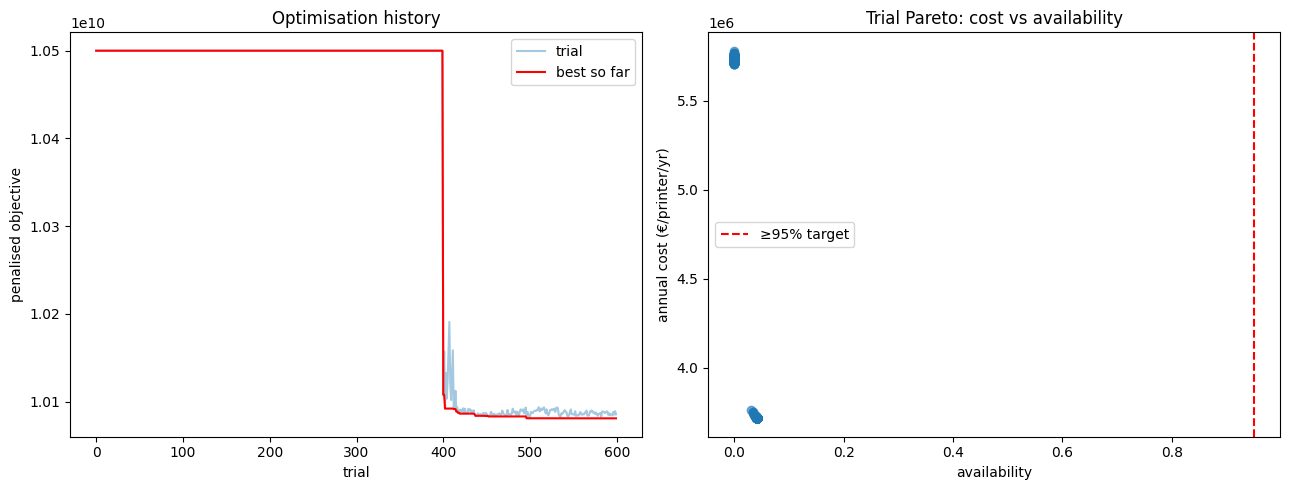

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
history = study.trials_dataframe().dropna(subset=['value'])
axes[0].plot(history['number'], history['value'], alpha=0.4, label='trial')
axes[0].plot(history['number'], history['value'].cummin(), color='red', label='best so far')
axes[0].set_xlabel('trial')
axes[0].set_ylabel('penalised objective')
axes[0].set_title('Optimisation history')
axes[0].legend()

study_df = study.trials_dataframe().dropna(subset=['user_attrs_annual_cost', 'user_attrs_availability'])
study_df = study_df.rename(columns={
    'user_attrs_annual_cost': 'annual_cost',
    'user_attrs_availability': 'availability',
})
plot_pareto_cost_availability(study_df, ax=axes[1])
axes[1].set_title('Trial Pareto: cost vs availability')
plt.tight_layout()
plt.show()

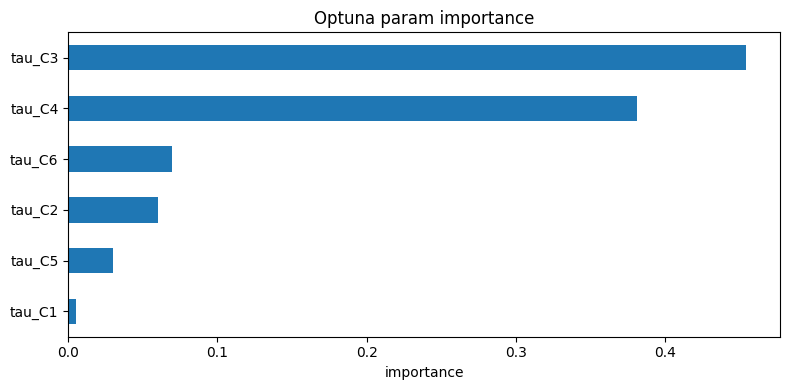

In [9]:
try:
    importance = optuna.importance.get_param_importances(study)
    pd.Series(importance).sort_values().plot(kind='barh', figsize=(8, 4), title='Optuna param importance')
    plt.xlabel('importance')
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print('Importance unavailable:', exc)